# Dynamical Systems Playground

Minimal examples for rolling out and visualizing a few systems.

In [1]:
from pathlib import Path
import sys

import torch
from IPython.display import Video, display

root = Path.cwd()
for p in (root, *root.parents):
    if (p / "src" / "DynamicalSystems").exists():
        sys.path.insert(0, str(p))
        break

from src.DynamicalSystems import (
    BinaryCA1D,
    BinaryCA2D,
    CoupledLogistic1D,
    GrayScott2D,
    LangtonCA2D,
    OuterTotalisticCA1D,
)

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [2]:
def describe(rollout):
    print(
        f"{rollout.system_name}: shape={tuple(rollout.tensor.shape)}, "
        f"discrete={rollout.is_discrete}, states={rollout.num_states}, "
        f"spatial_dim={rollout.spatial_dim}"
    )


def show(rollout, *, t=-1, normalize=False):
    describe(rollout)
    display(rollout.visualize(t=t, normalize=normalize))


def show_video(rollout, filename, *, fps=12, normalize=False):
    describe(rollout)
    path = rollout.visualize_video(filename=filename, fps=fps, normalize=normalize)
    display(Video(path, embed=True))

## 1D binary CA

BinaryCA1D: shape=(1, 160, 1, 192), discrete=True, states=2, spatial_dim=1


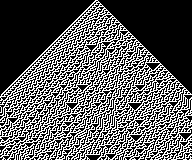

In [3]:
ca = BinaryCA1D(kernel_size=3, device=device)
params = ca.sample_params(B=1, device=device, kernel_size=3, rule_int=30)
x0 = ca.seed(B=1, W=192, mode="single")
rollout = ca.rollout(x0, params, steps=160)
show(rollout)

## 1D outer-totalistic CA

OuterTotalisticCA1D: shape=(1, 160, 1, 192), discrete=True, states=2, spatial_dim=1


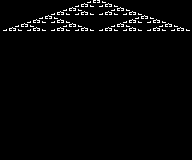

In [4]:
ca = OuterTotalisticCA1D(kernel_size=7, device=device)
params = ca.from_desc("B1/S12", B=1, kernel_size=7, device=device)
x0 = ca.seed(B=1, W=192, mode="single")
rollout = ca.rollout(x0, params, steps=160)
show(rollout)

## 2D Conway life

In [10]:
ca = BinaryCA2D(device=device)
params = {"rule": ca.bs_rule("B3/S23", device=device)}
x0 = ca.seed(B=1, H=256, W=256, mode="noise", p=0.5)
rollout = ca.rollout(x0, params, steps=120, every=2)
show_video(rollout, "conway_life.mp4", fps=12)

BinaryCA2D: shape=(1, 60, 1, 256, 256), discrete=True, states=2, spatial_dim=2


## 2D Langton CA

In [6]:
ca = LangtonCA2D(num_states=4, kernel_size=3, device=device)
params = ca.sample_params(B=1, device=device, lambda_=0.55, seed=42)
x0 = ca.seed(B=1, H=96, W=96, mode="noise")
rollout = ca.rollout(x0, params, steps=120, every=2)
show_video(rollout, "langton_ca_2d.mp4", fps=12)

LangtonCA2D: shape=(1, 60, 1, 96, 96), discrete=True, states=4, spatial_dim=2


## 1D coupled logistic lattice

CoupledLogistic1D: shape=(1, 240, 1, 256), discrete=False, states=None, spatial_dim=1


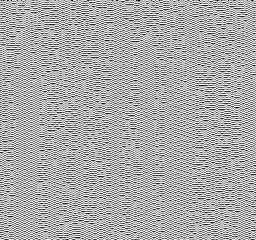

In [7]:
ca = CoupledLogistic1D(device=device)
params = ca.sample_params(B=1, device=device, r=(3.8, 3.8), eps=(0.25, 0.25))
x0 = ca.seed(B=1, W=256, mode="noise")
rollout = ca.rollout(x0, params, steps=240)
show(rollout, normalize=True)

## 2D Gray-Scott

In [8]:
ca = GrayScott2D(device=device)
params = ca.sample_params(B=1, device=device)
x0 = ca.seed(B=1, H=96, W=96, noise=0.02)
rollout = ca.rollout(x0, params, steps=800, every=20)
show_video(rollout, "gray_scott_2d.mp4", fps=12)

GrayScott2D: shape=(1, 40, 2, 96, 96), discrete=False, states=None, spatial_dim=2
